In [1]:
import torch
import physics_modelling.N_layer_system as pms
import physics_modelling.subsystems as s
import training_testing.target_class as tc
import training_testing.train_validate as tv
import training_testing.digits_generator as dg
import training_testing.npcc as cc
import imperfection_testing.extract_modulation as em
import imperfection_testing.misalignment_classes as mc
import imperfection_testing.accuracy_plot as ap
import csv
import dataclasses as dc
import matplotlib.pyplot as plt

In [2]:
import importlib
importlib.reload(mc)

<module 'imperfection_testing.misalignment_classes' from 'c:\\Users\\georg\\OneDrive\\Documents\\4th_year\\optical computing\\d2nn_misalign\\imperfection_testing\\misalignment_classes.py'>

General configuration params

In [3]:
config = s.OpticalConfig(
    532e-9,
    5e-6,
    256,
    256,
    4e-3
)

distance = 0.2 

# assume all distances the same
def distances(n):
    return distance*torch.ones(n+1).unsqueeze(0)

distances_list = []

for i in range(6):
    distances_list.append(distances( i + 1))

In [4]:
train_size = 512
val_size = 4096
batch_size = 64
train_loader, val_loader = dg.data_set_generation(config.height, config.width, train_size, val_size, batch_size)
criterion = cc.npcc_loss
target_pos = 50
half_target_size = 10
target_method = tc.targets(config.height, config.width, target_pos, target_pos, half_target_size)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = cc.npcc_loss

testing_config = tv.TestConfig(criterion,
                               val_loader,
                               target_method
                               )

In [5]:
files = ['training_testing/training_system/d2nn1/nn50.pt',
         'training_testing/training_system/d2nn2/nn35.pt',
         'training_testing/training_system/d2nn3/round2/nn3.pt',
         'training_testing/training_system/d2nn4/nn22.pt',
         'training_testing/training_system/d2nn5/nn44.pt',
         'training_testing/training_system/d2nn6/2/nn35.pt'
         ]
layers = [1,2,3,4,5,6]

The misalignment configs for different experiments, the n_samples=1 is because I'm running without GPU

In [6]:
z_misalignment_configs = []
tilt_misalignment_configs = []
xy_misalignment_configs = []
beam_tilt_misalignment_configs = []

for i in range (6):

    zero_1 = torch.zeros(i+2)
    zero_2 = torch.zeros(i+3)

    one_1 = torch.ones(i+2)
    one_2 = zero_2.clone()
    one_2[1:] = one_1
    
    tilt_misalignment_configs.append(mc.MisalignConfig(one_1,
                                                       zero_2,
                                                       zero_1,
                                                       False,
                                                       1
                                                    ))
    
    xy_misalignment_configs.append(mc.MisalignConfig(zero_1,
                                                         one_2,
                                                         zero_1,
                                                         True,
                                                         1
                                                    ))
    
    z_misalignment_configs.append(mc.MisalignConfig(zero_1,
                                                    zero_2,
                                                    one_1,
                                                    False,
                                                    1
                                                    ))
    
    only_one = torch.zeros(i+2)
    only_one[0] = 1
    beam_tilt_misalignment_configs.append(mc.MisalignConfig(only_one,
                                                             zero_2,
                                                             zero_1,
                                                             False,
                                                             1
                                                             ))
    

In [10]:
import importlib
importlib.reload(ap)

<module 'imperfection_testing.accuracy_plot' from 'c:\\Users\\georg\\OneDrive\\Documents\\4th_year\\optical computing\\d2nn_misalign\\imperfection_testing\\accuracy_plot.py'>

taking accuracy and std dev at a given scale

In [7]:
def acc_m_std_dev( misalignment_config,  
                  N_layers, 
                  n_samples, 
                  scale,
                  input_file,
                  tilt_v_xy = False
                  ):
    '''
    for an experiment defined by mis_con at a particukar scale
    runs accuracies for all samples, then calculated mean and standard deviation
    takes the mean and standard deviation of samples at that scale
    '''
    
    N_layers_1 = N_layers - 1

    accs = torch.zeros(n_samples)

    for i in range ( n_samples ):
        
        system = mc.Misalign(config,
                             distances_list[ N_layers_1 ],
                             False,
                             misalignment_config,
                             scale,
                             input_file,
                             tilt_v_xy
                             )
        
        _, acc, _, _ = tv.validation(system, 
                                     val_loader, 
                                     criterion, 
                                     target_method, 
                                     device
                                     )
        
        # convert to %
        accs[i] = 100 * acc

    acc_mean = torch.mean(accs).item()
    
    if accs.size(0) == 1:
        acc_std = 0
    else:
        acc_std = torch.std(accs).item()

    return acc_mean, acc_std



Running an entire experiment for just one type of misalignment over all 5 systems

In [9]:
def save_csv(file, header, rows, append):
    
    mode = 'a' if append else 'w'

    with open(file, mode, newline='') as f:
        writer = csv.writer(f)

        if not append:
            writer.writerow(header)

        writer.writerows(rows)

In [8]:
def full_experiment(misalignment_config, 
                    n_samples, 
                    scales, 
                    chosen_field, 
                    destination_file,
                    input_files,
                    append=False,
                    tilt_v_xy = False,
                    ):
    '''
    assumes one field
    scales is a list of the scales in this field
    for chosen_field, 0,1,2 indicates tilt, xy_displacement, z_displacement
    destination_file is where you wan the data saved
    '''
    header = ['N_layers']
    header = header + scales
    rows = []
    
    for i, input_file in input_files:

        row_mean = [ i ]
        row_std = [ f'{i}_std']

        for j, scale in enumerate(scales):

            scale_tensor = torch.zeros(3)
            scale_tensor[ chosen_field ] = scale
            acc_mean, acc_std = acc_m_std_dev( misalignment_config[i - 1], 
                                           i, 
                                           n_samples[j], 
                                           scale_tensor,
                                           input_file,
                                           tilt_v_xy
                                           )
            
            row_mean.append( acc_mean )
            row_std.append( acc_std )

        rows.append(row_mean)
        rows.append(row_std)
        print(f'results for {i} layers: means: {row_mean}, std: {row_std}')

    save_csv(destination_file, header, rows, append)
            
            


Experiments for xy

In [ ]:
xy_displacement = [0, 1e-6,3e-6,5e-6,7e-6,9e-6,15e-6,20e-6]
samples = [1,5,10,10,10,10,10,10]
full_experiment(xy_misalignment_configs,
                samples,
                xy_displacement,
                1,
                'xy_misalignment.csv'
                )



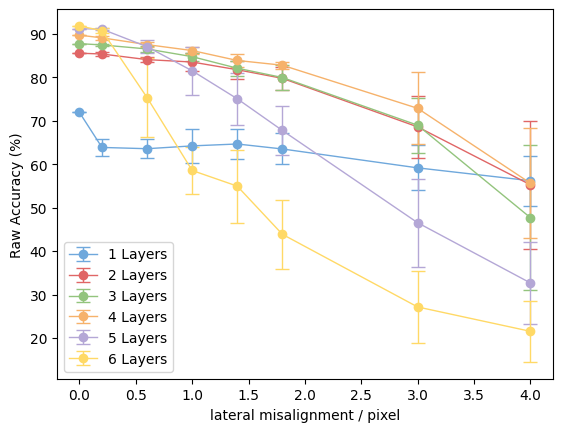

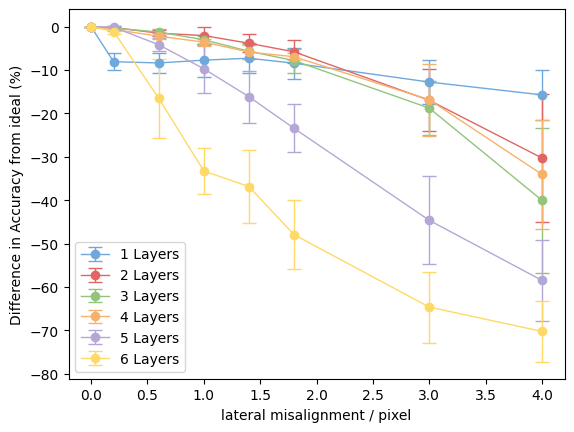

In [11]:
ap.plot_acc('xy_misalignment.csv',
            'lateral misalignment / pixel',
            1/config.pixel_size
            )

ap.plot_acc('xy_misalignment.csv',
            'lateral misalignment / pixel',
            1/config.pixel_size,
            difference=True
            )

Experiment for tilt

In [ ]:
tilt = (torch.tensor(xy_displacement) * 5 ).tolist()
full_experiment(tilt_misalignment_configs_2,
                samples,
                tilt,
                0,
                'tilt_misalignment.csv'
                )

results for 1 layers: means: [1, 71.2646484375, 71.3818359375, 71.47216796875, 71.2060546875, 70.93994140625, 70.06591796875, 68.193359375, 64.98291015625], std: ['1_std', 0, 0.07201113551855087, 0.15235714614391327, 0.3047577440738678, 0.6403800249099731, 0.6850889325141907, 1.7322633266448975, 2.894712448120117]
results for 2 layers: means: [2, 84.619140625, 84.6923828125, 84.3408203125, 83.75244140625, 83.4814453125, 82.55126953125, 79.25048828125, 65.966796875], std: ['2_std', 0, 0.11835155636072159, 0.2436518520116806, 0.736322283744812, 0.876960039138794, 1.3020858764648438, 3.300917148590088, 12.088470458984375]
results for 3 layers: means: [3, 87.6220703125, 87.607421875, 87.45361328125, 87.0849609375, 86.29150390625, 85.9130859375, 82.5830078125, 72.56103515625], std: ['3_std', 0, 0.1510912925004959, 0.19614149630069733, 0.3580729067325592, 0.758300244808197, 0.9354830980300903, 3.396279811859131, 11.693469047546387]
results for 4 layers: means: [4, 88.671875, 88.6376953125, 8

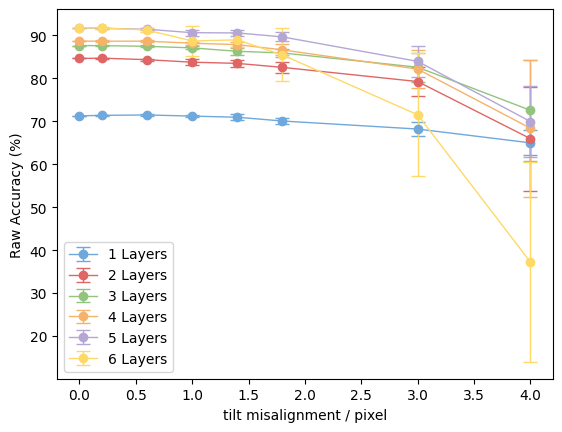

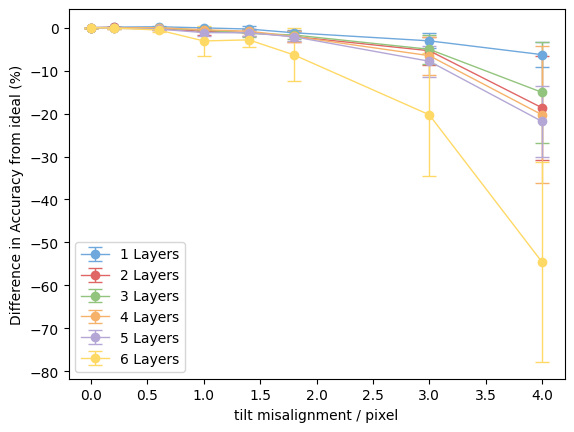

In [12]:
scale = distance/config.pixel_size

ap.plot_acc('tilt_misalignment.csv',
            'tilt misalignment / pixel',
            scale
            )

ap.plot_acc('tilt_misalignment.csv',
            'tilt misalignment / pixel',
            scale,
            difference=True
            )

Experiment for z displacement

In [127]:
z_displacements = [ 0, 5e-5, 1e-4, 3e-4, 5e-4, 8e-4, 1e-3, 2e-3 ]
full_experiment(z_misalignment_configs,
                samples,
                z_displacements,
                2,
                'z_misalignment.csv'
                )

results for 1 layers: means: [1, 71.2646484375, 71.5869140625, 71.2060546875, 71.11083984375, 70.48095703125, 69.02587890625, 64.40673828125, 47.6025390625], std: ['1_std', 0, 0.30610209703445435, 0.3349860906600952, 0.9129140377044678, 1.9347774982452393, 3.1361286640167236, 6.118714332580566, 7.641257286071777]
results for 2 layers: means: [2, 84.619140625, 84.47265625, 84.34814453125, 83.31787109375, 83.0126953125, 82.87353515625, 82.7294921875, 81.72119140625], std: ['2_std', 0, 0.3005013167858124, 0.45433923602104187, 0.6492131352424622, 0.5727686882019043, 0.6490294933319092, 0.969497561454773, 1.3320053815841675]
results for 3 layers: means: [3, 87.6220703125, 87.3486328125, 86.796875, 86.07177734375, 85.517578125, 84.794921875, 84.20166015625, 83.5107421875], std: ['3_std', 0, 0.20382452011108398, 0.4909594655036926, 0.6767047047615051, 0.773223340511322, 1.000864028930664, 1.0433470010757446, 0.898814857006073]
results for 4 layers: means: [4, 88.671875, 88.41796875, 87.844238

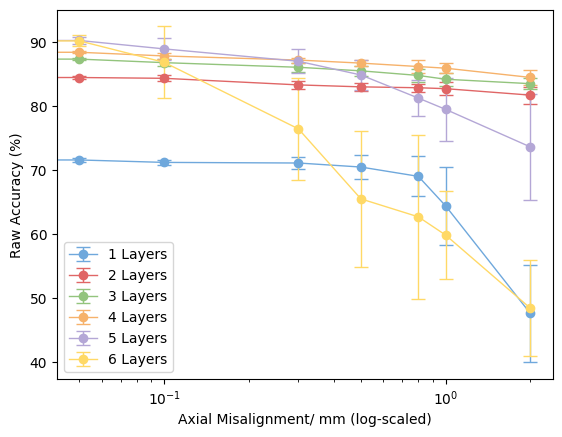

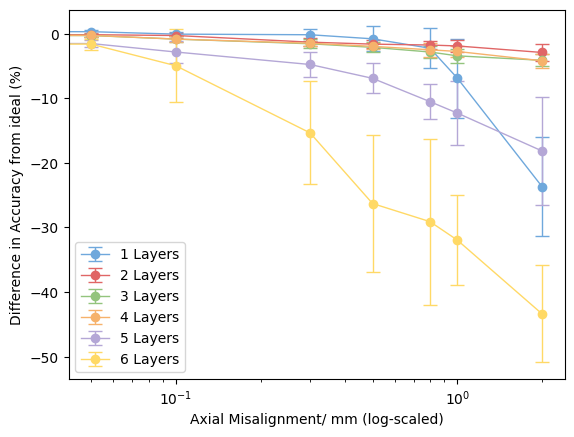

In [17]:
scale = distance/config.pixel_size

ap.plot_acc('z_misalignment.csv',
            'Axial Misalignment/ mm (log-scaled)',
            log  =True,
            x_scale_factor=1e3
            )

ap.plot_acc('z_misalignment.csv',
            'Axial Misalignment/ mm (log-scaled)',
            difference=True,
            log = True,
            x_scale_factor = 1e3
            )


Experiment for tilt and displacement cancelled

In [ ]:

xy_tilt = [0, 1e-6, 5e-6, 10e-6, 20e-6, 1e-4, 1e-3, 1e-2]
samples = [1,5,10,10,10,10,10,10,10]
full_experiment(xy_misalignment_configs,
                samples,
                xy_tilt,
                1,
                'xy_tilt.csv',
                True
                )

results for 1 layers: means: [1, 72.0458984375, 65.1708984375, 65.810546875, 66.50146484375, 68.09326171875, 63.9404296875, 54.47265625, 9.82421875], std: ['1_std', 0, 4.617634296417236, 3.460280418395996, 3.9868903160095215, 3.60345196723938, 2.1935853958129883, 5.599358081817627, 2.5567169189453125]
results for 2 layers: means: [2, 85.64453125, 85.3955078125, 84.0869140625, 84.17724609375, 83.92822265625, 83.45458984375, 83.40087890625, 9.7900390625], std: ['2_std', 0, 0.18056505918502808, 0.3228241205215454, 0.6732903122901917, 0.8222261071205139, 0.5037757158279419, 0.7366099953651428, 3.227133274078369]
results for 3 layers: means: [3, 87.646484375, 87.2265625, 85.1416015625, 85.0732421875, 84.27490234375, 84.23828125, 84.36767578125, 10.8056640625], std: ['3_std', 0, 0.2580278813838959, 0.7360478639602661, 0.9644293189048767, 1.1136577129364014, 0.7603890895843506, 0.964212954044342, 2.387984275817871]
results for 4 layers: means: [4, 89.4287109375, 88.96484375, 86.69189453125, 8

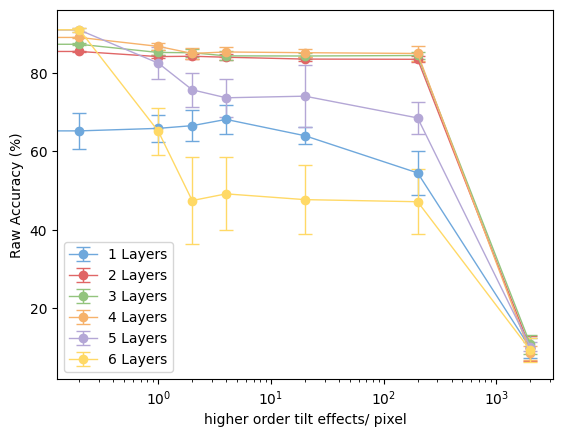

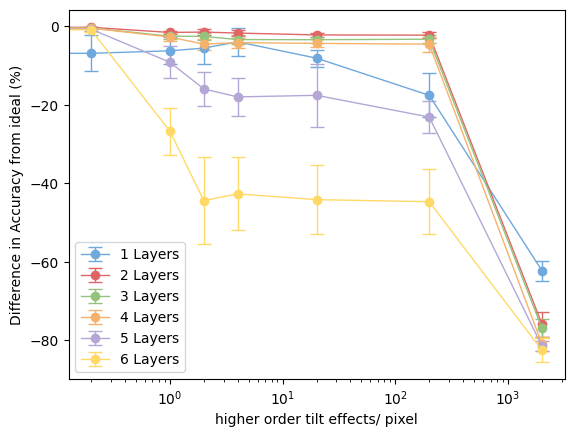

In [19]:
ap.plot_abs_and_diff('xy_tilt.csv',
                     'higher order tilt effects/ pixel',
                     x_scale_factor=1/config.pixel_size,
                     log=True
                     )

In [32]:
file = [(6,'training_testing/training_system/d2nn6/2/nn35.pt')]

xy_displacement = [0, 1e-6,3e-6,5e-6,7e-6,9e-6,15e-6,20e-6]

samples = [1,5,10,10,10,10,10,10]

full_experiment(xy_misalignment_configs,
                samples,
                xy_displacement,
                1,
                'xy_misalignment.csv',
                file,
                True
                )

tilt = (torch.tensor(xy_displacement) * 5 ).tolist()
full_experiment(tilt_misalignment_configs,
                samples,
                tilt,
                0,
                'tilt_misalignment.csv',
                file,
                True
                )

z_displacements = [ 0, 5e-5, 1e-4, 3e-4, 5e-4, 8e-4, 1e-3, 2e-3 ]

full_experiment(z_misalignment_configs,
                samples,
                z_displacements,
                2,
                'z_misalignment.csv',
                file,
                True
                )

xy_tilt = [0, 1e-6, 5e-6, 10e-6, 20e-6, 1e-4, 1e-3, 1e-2]

samples_2 = [1,5,10,10,10,10,10,10,10]

full_experiment(xy_misalignment_configs,
                samples_2,
                xy_tilt,
                1,
                'xy_tilt.csv',
                file,
                True
                )

results for 7 layers: means: [6, 91.796875, 90.6982421875, 75.3125, 58.54248046875, 54.94140625, 43.8623046875, 27.14599609375, 21.54296875], std: ['6_std', 0, 0.5216274857521057, 9.141644477844238, 5.364375114440918, 8.387312889099121, 7.884059906005859, 8.176515579223633, 7.0407304763793945]
results for 7 layers: means: [6, 91.796875, 91.7138671875, 91.2353515625, 88.69873046875, 88.95263671875, 85.44921875, 71.51611328125, 37.24609375], std: ['6_std', 0, 0.1510912925004959, 0.3650335669517517, 3.4993386268615723, 1.6988495588302612, 6.184307098388672, 14.292631149291992, 23.26202392578125]
results for 7 layers: means: [6, 91.796875, 90.1953125, 86.84326171875, 76.44287109375, 65.50537109375, 62.69775390625, 59.8486328125, 48.42041015625], std: ['6_std', 0, 0.8468900322914124, 5.629739761352539, 7.98925256729126, 10.59122371673584, 12.866292953491211, 6.898317813873291, 7.511080741882324]
results for 7 layers: means: [6, 91.796875, 90.458984375, 66.43798828125, 44.23828125, 19.057617

In [33]:
xy_tilt = [0, 1e-6, 5e-6, 10e-6, 20e-6, 1e-4, 1e-3, 1e-2]

samples_2 = [1,5,10,10,10,10,10,10,10]

full_experiment(xy_misalignment_configs,
                samples_2,
                xy_tilt,
                1,
                'xy_tilt.csv',
                file,
                True,
                True
                )

results for 7 layers: means: [6, 91.796875, 90.908203125, 65.09521484375, 47.431640625, 49.1357421875, 47.666015625, 47.13134765625, 9.31396484375], std: ['6_std', 0, 0.5493435263633728, 6.011040210723877, 11.06721019744873, 9.29198169708252, 8.752229690551758, 8.328104019165039, 3.0747129917144775]


In [34]:
file = [(6,'training_testing/training_system/d2nn6/2/nn35.pt')]

xy_displacement = [0, 1e-6,3e-6,5e-6,7e-6,9e-6,15e-6,20e-6]

samples = [1,5,10,10,10,10,10,10]

full_experiment(xy_misalignment_configs,
                samples,
                xy_displacement,
                1,
                'xy_misalignment.csv',
                files,
                True
                )

results for 2 layers: means: [1, 71.8994140625, 63.8427734375, 63.55224609375, 64.19921875, 64.63623046875, 63.4912109375, 59.1455078125, 56.1865234375], std: ['1_std', 0, 1.944331407546997, 2.222304105758667, 3.8320868015289307, 3.4835150241851807, 3.569451332092285, 5.147247791290283, 5.707615852355957]
results for 3 layers: means: [2, 85.5224609375, 85.3369140625, 84.04541015625, 83.4912109375, 81.71875, 79.7412109375, 68.5693359375, 55.2587890625], std: ['2_std', 0, 0.3644161820411682, 0.6212940812110901, 1.9870706796646118, 2.044532537460327, 2.6318867206573486, 7.192741870880127, 14.687169075012207]
results for 4 layers: means: [3, 87.7197265625, 87.421875, 86.4990234375, 84.72412109375, 82.0654296875, 79.9267578125, 68.95751953125, 47.69775390625], std: ['3_std', 0, 0.2480161190032959, 0.6373686194419861, 0.8974764943122864, 1.725920557975769, 2.765773057937622, 6.313417911529541, 16.674222946166992]
results for 5 layers: means: [4, 89.6728515625, 89.052734375, 87.49755859375, 8

In [8]:
import imperfection_testing.misalignment_sweep as ms
importlib.reload(ms)

file_zip = list(zip(layers, files, distances_list, xy_misalignment_configs))


xy_displacement = [0, 1e-6,3e-6,5e-6,7e-6,9e-6,15e-6,20e-6]
samples = [1,5,10,10,10,10,10,10]
scale_samples = list(zip(xy_displacement, samples))
'''
config,
                    distances,
                    misalignment_config, 
                    testing_config,
                    chosen_field,
                    scales_samples,
                    destination_file,
                    input_files,
                    append=False,
'''

ms.full_experiment(config,
                   distances,
                   xy_misalignment_configs,
                   testing_config,
                   1,
                scale_samples,
                'tilt_misalignment_1.csv',
                file_zip
                )

results for 1 layers: means: [1, 70.5322265625, 70.6640625, 70.32958984375, 69.57763671875, 69.0625, 67.37548828125, 62.01416015625, 58.30078125], std: ['1_std', 0, 0.2408221811056137, 0.3285684883594513, 0.5407284498214722, 1.1881399154663086, 1.296836495399475, 4.719581127166748, 6.65501070022583]
results for 2 layers: means: [2, 84.1552734375, 84.1552734375, 83.9306640625, 83.02734375, 81.5380859375, 80.58837890625, 69.52392578125, 54.51171875], std: ['2_std', 0, 0.11320335417985916, 0.26490476727485657, 0.9330587983131409, 1.2703031301498413, 2.3554320335388184, 8.969228744506836, 21.860525131225586]
results for 3 layers: means: [3, 87.59765625, 87.4755859375, 87.1484375, 86.5869140625, 85.83251953125, 85.14892578125, 79.2626953125, 63.36669921875], std: ['3_std', 0, 0.07524919509887695, 0.2537705898284912, 0.6506549715995789, 1.207450270652771, 1.838474154472351, 5.5951385498046875, 15.781900405883789]
results for 4 layers: means: [4, 88.4765625, 88.5400390625, 88.48388671875, 88.